### Предварительные действия

In [38]:
# Базовые библиотеки
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import joblib
# Разбиение на train/test и метрики качества
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier

#Метрики качества
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


from pathlib import Path
import json

RANDOM_STATE = 42
ARTIFACTS_DIR = Path("artifacts")

### Загрузка данных и первичный анализ

In [2]:
dataset = pd.read_csv('S06-hw-dataset-03.csv')
df = pd.DataFrame(dataset)

In [3]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f20,f21,f22,f23,f24,f25,f26,f27,f28,target
0,1,-2.721419,0.652294,1.867234,-0.245331,-0.241182,-0.195509,1.180193,-0.724816,1.804165,...,0.042851,-0.153232,1.566167,-1.516125,-1.586857,-3.998937,-1.308459,2.155125,1.992519,0
1,2,-4.191520,-0.647731,-0.881929,-0.968159,3.530725,-4.858592,0.240979,-0.714017,0.285769,...,-1.170056,0.631661,1.277915,-0.464432,1.927986,6.034154,0.149833,4.861592,-3.547303,0
2,3,-0.582739,0.415128,-4.205613,-0.320853,0.313570,-2.655451,2.215387,1.492222,-0.516727,...,0.083281,-0.757912,5.672669,-0.283472,0.275362,-0.988055,0.940883,-3.050749,-0.703865,1
3,4,-1.766082,1.253523,1.610804,0.466067,3.837868,-3.564073,-1.831031,1.066265,-0.198636,...,-0.674648,1.780285,-4.718432,0.711573,1.705610,6.474380,-1.690537,8.687735,-2.799399,0
4,5,-2.157834,-1.361285,-0.917199,0.937285,0.408551,-0.062032,-0.480196,-0.554454,-1.026434,...,-0.096277,0.212875,1.710699,2.476220,0.669305,3.166072,-0.718493,3.630457,0.083986,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      15000 non-null  int64  
 1   f01     15000 non-null  float64
 2   f02     15000 non-null  float64
 3   f03     15000 non-null  float64
 4   f04     15000 non-null  float64
 5   f05     15000 non-null  float64
 6   f06     15000 non-null  float64
 7   f07     15000 non-null  float64
 8   f08     15000 non-null  float64
 9   f09     15000 non-null  float64
 10  f10     15000 non-null  float64
 11  f11     15000 non-null  float64
 12  f12     15000 non-null  float64
 13  f13     15000 non-null  float64
 14  f14     15000 non-null  float64
 15  f15     15000 non-null  float64
 16  f16     15000 non-null  float64
 17  f17     15000 non-null  float64
 18  f18     15000 non-null  float64
 19  f19     15000 non-null  float64
 20  f20     15000 non-null  float64
 21  f21     15000 non-null  float64
 22

In [5]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f20,f21,f22,f23,f24,f25,f26,f27,f28,target
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,-0.840416,-0.011530,0.755463,0.008092,-0.246559,0.992538,-0.004599,-0.005366,0.011024,...,0.008801,0.004798,-0.060611,-0.008095,0.002397,0.699377,-0.001170,1.380216,0.150765,0.612600
std,4330.271354,1.785432,1.007374,3.663136,0.996556,2.216202,3.943110,2.113607,1.001960,1.006309,...,0.988931,0.999959,3.747823,0.994912,0.990567,3.801468,0.996588,3.929134,2.005847,0.740016
min,1.000000,-8.199174,-4.100091,-13.591257,-3.992807,-8.243563,-14.950758,-8.522298,-3.768197,-3.791645,...,-3.612116,-4.150852,-15.977469,-3.664246,-3.857890,-16.273835,-4.536600,-12.105957,-8.300728,0.000000
25%,3750.750000,-2.029608,-0.686265,-1.593729,-0.674039,-1.738188,-1.580544,-1.380091,-0.673001,-0.661451,...,-0.674236,-0.669654,-2.517892,-0.676471,-0.661098,-1.842677,-0.668133,-1.339314,-1.235425,0.000000
50%,7500.500000,-0.855943,-0.010454,0.744919,0.009431,-0.203512,1.110848,0.134466,-0.003663,0.004158,...,0.020916,0.010701,0.019034,-0.001622,0.001807,0.780608,-0.007763,1.108728,0.137089,0.000000
75%,11250.250000,0.313482,0.674347,3.057234,0.677459,1.254102,3.700201,1.443666,0.662753,0.683465,...,0.681036,0.676786,2.521745,0.659456,0.663270,3.297387,0.676626,3.869991,1.524830,1.000000
max,15000.000000,7.338969,4.418126,17.965154,3.887820,8.542916,15.618988,7.575797,3.698010,3.963730,...,3.497004,3.828639,12.661894,4.214633,4.378893,17.152063,3.618447,18.906060,8.007400,2.000000


In [6]:
#Распределение таргета target (доли классов)
print(df['target'].value_counts(normalize=True))

target
0    0.542533
1    0.302333
2    0.155133
Name: proportion, dtype: float64


In [7]:
#Проверка пропусков
print(df.isna().sum())

id        0
f01       0
f02       0
f03       0
f04       0
f05       0
f06       0
f07       0
f08       0
f09       0
f10       0
f11       0
f12       0
f13       0
f14       0
f15       0
f16       0
f17       0
f18       0
f19       0
f20       0
f21       0
f22       0
f23       0
f24       0
f25       0
f26       0
f27       0
f28       0
target    0
dtype: int64


In [8]:
#Типы столбцов
print(df.dtypes)

id          int64
f01       float64
f02       float64
f03       float64
f04       float64
f05       float64
f06       float64
f07       float64
f08       float64
f09       float64
f10       float64
f11       float64
f12       float64
f13       float64
f14       float64
f15       float64
f16       float64
f17       float64
f18       float64
f19       float64
f20       float64
f21       float64
f22       float64
f23       float64
f24       float64
f25       float64
f26       float64
f27       float64
f28       float64
target      int64
dtype: object


In [31]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, average = 'macro')),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

In [30]:
#Определение X и y
X = df.copy().drop('id', axis = 1).drop('target', axis = 1)
y = df['target']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
best_models = {}
search_summaries = {} 

### Train/Test-сплит и воспроизводимость

In [32]:
#Делим данные на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2, 
    random_state = RANDOM_STATE, 
    stratify = y
)

- Фиксированный seed важен, чтобы при повтороном запуске выборка данных оставалось той же
- Стратификация важна, потому что она позоляет сохранить одинаковые пропорции train и split

### Baselin’ы

In [33]:
dummy = DummyClassifier(strategy = "most_frequent")
dummy.fit(X_train, y_train)

results.append(evaluate_on_test(dummy, X_test, y_test, "Dummy(most_frequent)"))
best_models["Dummy(most_frequent)"] = dummy

- Всегда предсказывает самый частый класс
- Accuracy показывает долю этого класса в данных
- F1-macro низкий, т.к. не угадывает редкие классы
- ROC-AUC около 0.5 (как случайное угадывание)

#### LogisticRegression

In [58]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty = 'l2', max_iter = 1000, random_state = RANDOM_STATE))
])

lr_grid = {
    "logreg__C": [0.1, 1.0, 10.0],
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs"]
}

lr_search = GridSearchCV(
    pipe, lr_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
best_models["LogisticRegression(scaled)"] = best_lr

search_summaries["LogisticRegression(scaled)"] = {
    "best_params": lr_search.best_params_,
    "best_cv_f1_macro": float(lr_search.best_score_),
}
results.append(evaluate_on_test(best_lr, X_test, y_test, "LogisticRegression(scaled)"))

## Модели недели 6

#### Дерево решений

In [59]:
tree_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state = RANDOM_STATE))
])

param_grid = {
    'tree__max_depth': [3, 5, 7, 10, None],      # глубина дерева
    'tree__min_samples_split': [2, 5, 10],       # мин. samples для разделения
    'tree__min_samples_leaf': [1, 2, 4],         # мин. samples в листе
    'tree__criterion': ['gini', 'entropy'] 
}

grid_search = GridSearchCV(
    estimator = tree_reg_pipe,
    param_grid = param_grid,
    scoring = 'f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_gd = grid_search.best_estimator_
best_models["DecisionTree"] = best_gd
search_summaries["DecisionTree"] = {
    "best_params": grid_search.best_params_,
    "best_cv_f1_macro": float(grid_search.best_score_),
}
results.append(evaluate_on_test(best_gd, X_test, y_test, "DecisionTree"))

search_summaries["DecisionTree"]

Fitting 5 folds for each of 90 candidates, totalling 450 fits


{'best_params': {'tree__criterion': 'gini',
  'tree__max_depth': 10,
  'tree__min_samples_leaf': 4,
  'tree__min_samples_split': 2},
 'best_cv_f1_macro': 0.7385146006505618}

#### Случайный лес

In [60]:
random_forest_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('forest', RandomForestClassifier(random_state = RANDOM_STATE))
])

rf_grid = {
    'forest__n_estimators': [50, 100],
    'forest__max_depth': [5, 10, None],
    'forest__min_samples_leaf': [1, 3, 5],
    'forest__max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    estimator = random_forest_pipe,
    param_grid = rf_grid,
    scoring = 'f1_macro',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

rf_grid_search.fit(X_train, y_train)

best_rf = rf_grid_search.best_estimator_
best_models["RandomForest"] = best_rf
search_summaries["RandomForest"] = {
    "best_params": rf_grid_search.best_params_,
    "best_cv_f1_macro": float(rf_grid_search.best_score_),
}
results.append(evaluate_on_test(best_rf, X_test, y_test, "RandomForest"))

search_summaries["RandomForest"]

Fitting 5 folds for each of 36 candidates, totalling 180 fits


{'best_params': {'forest__max_depth': None,
  'forest__max_features': 'sqrt',
  'forest__min_samples_leaf': 1,
  'forest__n_estimators': 100},
 'best_cv_f1_macro': 0.840198641267911}

#### GradientBoostingClassifier

In [72]:
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_grid = {
    'gb__n_estimators': [100, 150],
    'gb__learning_rate': [0.01, 0.05, 0.1],
    'gb__max_depth': [3, 5],
    'gb__min_samples_leaf': [10, 20]
}

gb_grid_search = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

best_gb = gb_grid_search.best_estimator_
best_models["GradientBoosting"] = best_gb
search_summaries["GradientBoosting"] = {
    "best_params": gb_grid_search.best_params_,
    "best_cv_f1_macro": float(gb_grid_search.best_score_),
}
results.append(evaluate_on_test(best_gb, X_test, y_test, "GradientBoosting"))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [73]:
search_summaries["GradientBoosting"]

{'best_params': {'gb__learning_rate': 0.1,
  'gb__max_depth': 5,
  'gb__min_samples_leaf': 10,
  'gb__n_estimators': 150},
 'best_cv_f1_macro': 0.8531113134372881}

#### HistGradientBoostingClassifier

In [74]:
hgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('hgb', HistGradientBoostingClassifier(random_state = RANDOM_STATE))
])

hgb_grid = {
    'hgb__max_iter': [100, 150, 200],               
    'hgb__learning_rate': [0.01, 0.05, 0.1],    
    'hgb__max_depth': [3, 5, 7],       
    'hgb__min_samples_leaf': [10, 20, 30],
}

hgb_grid_search = GridSearchCV(
    estimator = hgb_pipe,
    param_grid = hgb_grid,
    scoring = 'f1_macro',  
    cv = 4,
    n_jobs = -1,
    verbose = 1
)

hgb_grid_search.fit(X_train, y_train)

best_hgb = hgb_grid_search.best_estimator_
best_models["HistGradientBoosting"] = best_hgb
search_summaries["HistGradientBoosting"] = {
    "best_params": hgb_grid_search.best_params_,
    "best_cv_f1_macro": float(hgb_grid_search.best_score_),
}
results.append(evaluate_on_test(best_hgb, X_test, y_test, "HistGradientBoosting"))

search_summaries["HistGradientBoosting"]

Fitting 4 folds for each of 81 candidates, totalling 324 fits


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'best_params': {'hgb__learning_rate': 0.1,
  'hgb__max_depth': 7,
  'hgb__max_iter': 200,
  'hgb__min_samples_leaf': 20},
 'best_cv_f1_macro': 0.871864825021442}

#### StackingClassifier

In [75]:
estimators = [
    ("logreg", best_models["LogisticRegression(scaled)"]),
    ("forest", best_models["RandomForest"]),
    ("hgb", best_models["HistGradientBoosting"]),
]

stack = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression(max_iter=4000, random_state=RANDOM_STATE),
    cv = 5,
    n_jobs = -1,
    passthrough = False
)

stack.fit(X_train, y_train)
best_models["Stacking"] = stack
results.append(evaluate_on_test(stack, X_test, y_test, "Stacking"))

#### Сводка результатов 

In [76]:
df_results = pd.DataFrame(results)

df_sorted = df_results.drop('roc_auc', axis = 1)
df_sorted = df_sorted.sort_values('accuracy', ascending = False)
df_sorted

,accuracy,f1,model
8,0.906000,0.884661,Stacking
5,0.906000,0.884661,Stacking
1,0.900000,0.878103,HistGradientBoosting
7,0.900000,0.878103,HistGradientBoosting
4,0.893333,0.867131,RandomForest
6,0.884000,0.857519,GradientBoosting
3,0.795000,0.736638,DecisionTree
2,0.723667,0.665128,LogisticRegression(scaled)
0,0.542667,0.234515,Dummy(most_frequent)


In [89]:
'''def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def save_metrics_and_summaries():
    # 1. Сохраняем метрики в правильном формате
    metrics_data = []
    for _, row in df_sorted.iterrows():
        metrics_data.append({
            "model": row["model"],
            "accuracy": float(row["accuracy"]),
            "f1": float(row["f1"]),
            "roc_auc": row.get("roc_auc", None)  
        })
    
    metrics_path = ARTIFACTS_DIR / "metrics_test.json"
    save_json({"results": metrics_data}, metrics_path)
    print(f"Сохранено: {metrics_path}")
    
    # 2. Сохраняем search_summaries
    search_path = ARTIFACTS_DIR / "search_summaries.json"
    save_json(search_summaries, search_path)
    print(f"Сохранено: {search_path}")'''

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

# Подготовка данных для сохранения
metrics_data = []
for _, row in df_sorted.iterrows():
    metrics_data.append({
        "model": str(row["model"]),
        "accuracy": float(row["accuracy"]),
        "f1": float(row["f1"]),
        "roc_auc": float(row["roc_auc"]) if pd.notna(row.get("roc_auc")) else None
    })

# Вариант 1: Сохраняем как массив (самый простой для парсинга)
save_json(metrics_data, ARTIFACTS_DIR / "metrics_test.json")

search_path = ARTIFACTS_DIR / "search_summaries.json"
save_json(search_summaries, search_path)

#### Лучшая модель: диагностика на тесте (confusion matrix + ROC)

In [78]:
best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('Stacking',
 {'accuracy': 0.906, 'f1': 0.8846609028967555, 'model': 'Stacking'})

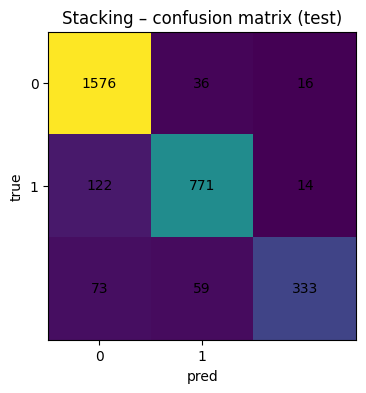

Сохранено: artifacts/figures/Stacking_confusion_matrix.png


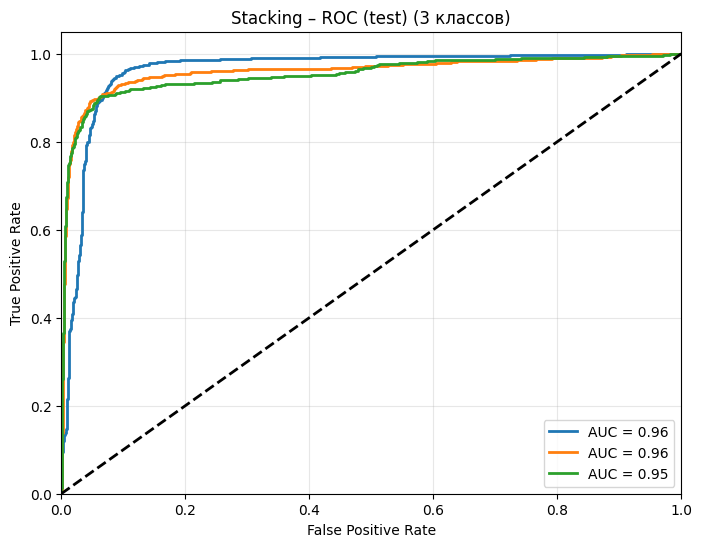

Сохранено: artifacts/figures/Stacking_roc_curve.png


In [79]:
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    
    # Проверяем сколько классов
    n_classes = len(np.unique(y_test))
    
    if n_classes == 2:
        # Бинарная классификация
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(title)
        plt.show()
    else:      
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        y_score = model.predict_proba(X_test)
        
        plt.figure(figsize=(8, 6))
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.2f}')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{title} ({n_classes} классов)')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

# Матрица ошибок
plot_confusion(y_test, y_pred, title=f"{best_label} – confusion matrix (test)")
plt.savefig(f'artifacts/figures/{best_label}_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()  
print(f"Сохранено: artifacts/figures/{best_label}_confusion_matrix.png")

# ROC кривая
plot_roc(best_model, X_test, y_test, title=f"{best_label} – ROC (test)")
plt.savefig(f'artifacts/figures/{best_label}_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()  
print(f"Сохранено: artifacts/figures/{best_label}_roc_curve.png")

#### Сохранение лучшей модели

In [86]:
'''model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")'''

# Подготовка метаданных с явным преобразованием типов
meta = {
    "best_model_label": str(best_label),
    "test_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row.get("roc_auc", 0)) if best_row.get("roc_auc") is not None else None
    },
    "search_summary": search_summaries.get(str(best_label), None),
    "random_state": int(RANDOM_STATE),
    "dataset": "S06-hw-dataset-03.csv",
    "target_classes": [int(x) for x in y.unique().tolist()]  # Преобразуем numpy int в Python int
}

# Сохраняем метаданные
meta_path = ARTIFACTS_DIR / "best_model_meta.json"
save_json(meta, meta_path)

#### Интерпретация: permutation importance (top‑15)

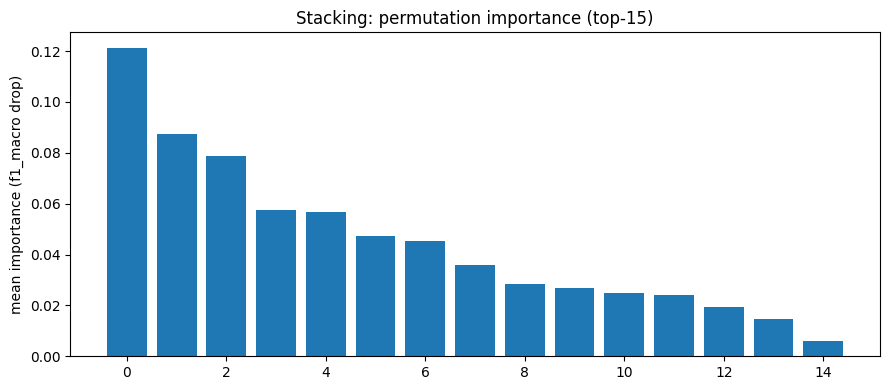

Сохранено: artifacts/figures/Stacking_permutation_importance.png


In [81]:
scoring = "f1_macro" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()

plt.savefig(f'artifacts/figures/{best_label}_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show() 
print(f"Сохранено: artifacts/figures/{best_label}_permutation_importance.png")